In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('creditcard.csv')

print("Total transactions:", len(df))
print("Fraud vs Normal:")
print(df['Class'].value_counts())
print(f"Fraud rate: {(df['Class']==1).mean()*100:.3f}%")

Total transactions: 284807
Fraud vs Normal:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.173%


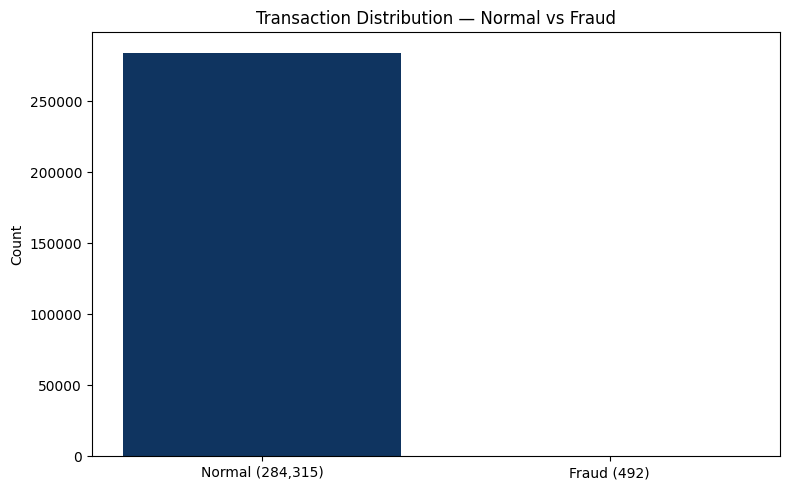


Key insight:
Only 492 frauds in 284,807 transactions
This is called CLASS IMBALANCE
Real banks face this every day!


In [2]:
# ── Chart 1: Fraud vs Normal Distribution ─────────────────────────────────
plt.figure(figsize=(8, 5))
plt.bar(['Normal (284,315)', 'Fraud (492)'],
        [284315, 492],
        color=['#0F3460', '#E94560'])
plt.title('Transaction Distribution — Normal vs Fraud')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('chart1_distribution.png', dpi=150)
plt.show()

print("\nKey insight:")
print("Only 492 frauds in 284,807 transactions")
print("This is called CLASS IMBALANCE")
print("Real banks face this every day!")

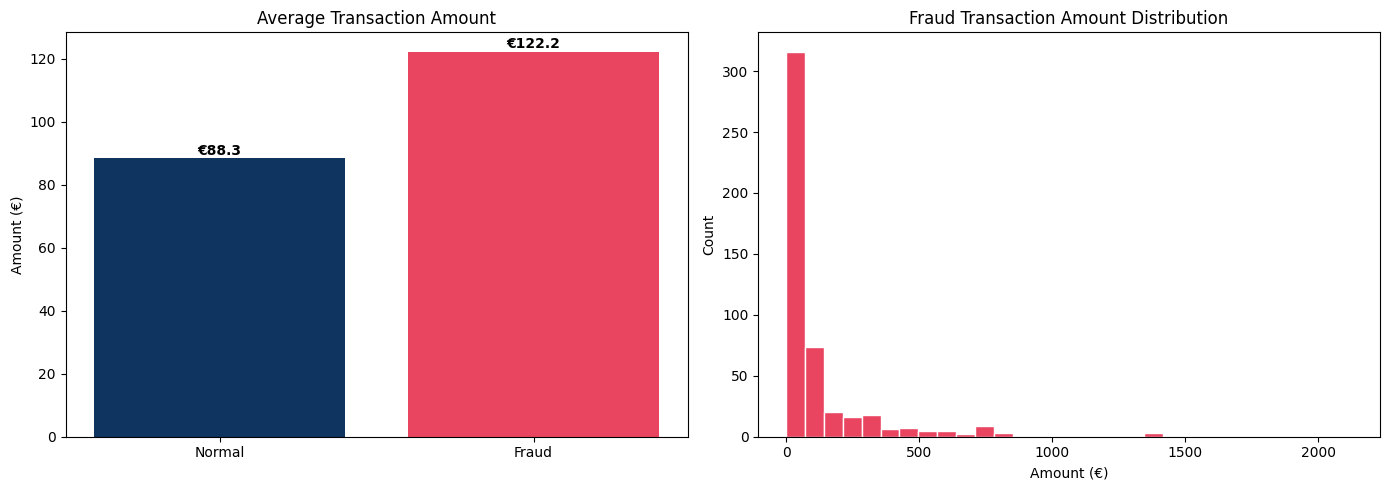

Average Normal transaction: €88.29
Average Fraud transaction: €122.21


In [3]:
# ── Chart 2: Transaction Amount — Fraud vs Normal ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Average amount comparison
avg_normal = df[df['Class']==0]['Amount'].mean()
avg_fraud = df[df['Class']==1]['Amount'].mean()

axes[0].bar(['Normal', 'Fraud'],
            [avg_normal, avg_fraud],
            color=['#0F3460', '#E94560'])
axes[0].set_title('Average Transaction Amount')
axes[0].set_ylabel('Amount (€)')
axes[0].text(0, avg_normal + 1, f'€{avg_normal:.1f}', ha='center', fontweight='bold')
axes[0].text(1, avg_fraud + 1, f'€{avg_fraud:.1f}', ha='center', fontweight='bold')

# Amount distribution of fraud transactions
axes[1].hist(df[df['Class']==1]['Amount'], 
             bins=30, color='#E94560', edgecolor='white')
axes[1].set_title('Fraud Transaction Amount Distribution')
axes[1].set_xlabel('Amount (€)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('chart2_amounts.png', dpi=150)
plt.show()

print(f"Average Normal transaction: €{avg_normal:.2f}")
print(f"Average Fraud transaction: €{avg_fraud:.2f}")

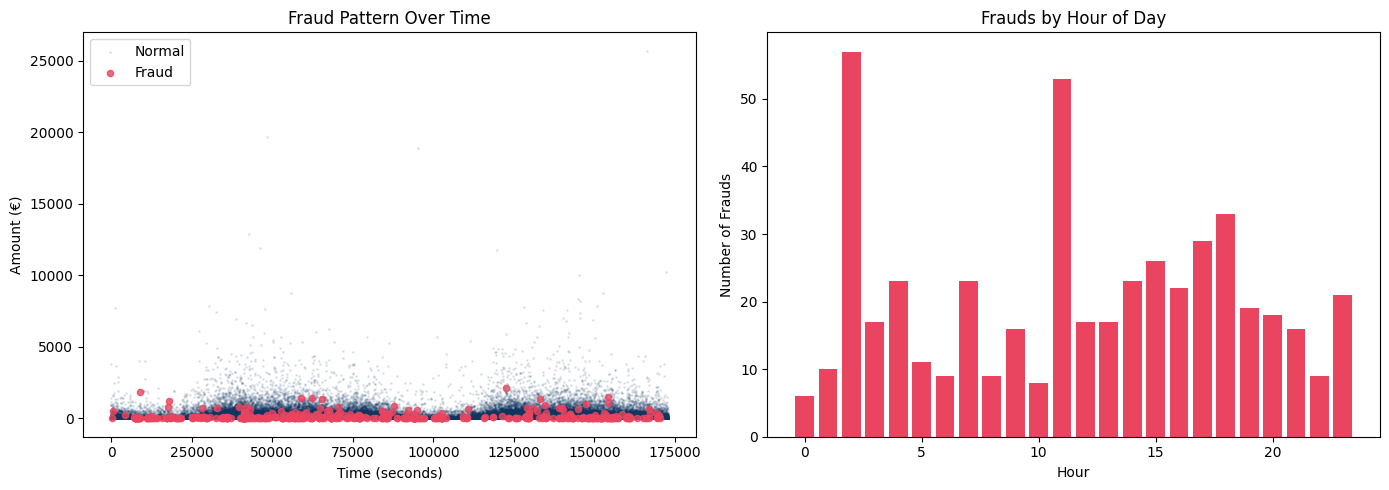

Key insight: Which hours have most frauds?
Hour
2.0     57
11.0    53
18.0    33
dtype: int64


In [4]:
# ── Chart 3: When do frauds happen? ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time distribution
axes[0].scatter(df[df['Class']==0]['Time'], 
                df[df['Class']==0]['Amount'],
                alpha=0.1, color='#0F3460', s=1, label='Normal')
axes[0].scatter(df[df['Class']==1]['Time'],
                df[df['Class']==1]['Amount'],
                alpha=0.8, color='#E94560', s=20, label='Fraud')
axes[0].set_title('Fraud Pattern Over Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amount (€)')
axes[0].legend()

# Fraud by time of day
df['Hour'] = (df['Time'] % 86400) // 3600
fraud_by_hour = df[df['Class']==1].groupby('Hour').size()
axes[1].bar(fraud_by_hour.index, fraud_by_hour.values, color='#E94560')
axes[1].set_title('Frauds by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Number of Frauds')

plt.tight_layout()
plt.savefig('chart3_timing.png', dpi=150)
plt.show()

print("Key insight: Which hours have most frauds?")
print(fraud_by_hour.sort_values(ascending=False).head(3))

=== Building Fraud Detection Model ===

Features: 31 columns
Total samples: 284807

Training samples: 227845
Testing samples: 56962

Training model... please wait...
Model trained!

=== Model Results ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.81      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighted avg       1.00      1.00      1.00     56962



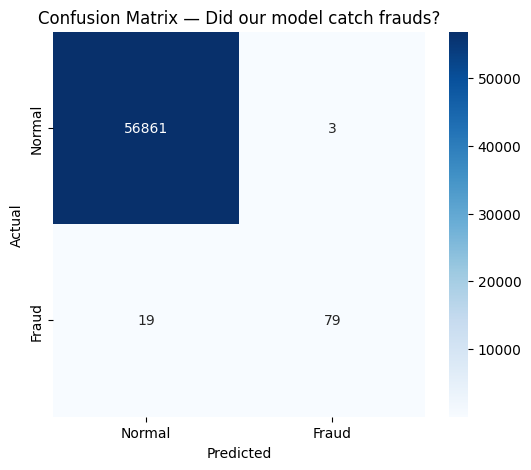

In [5]:
# ── ML Model: Fraud Detection ─────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("=== Building Fraud Detection Model ===\n")

# Step 1 — Prepare data
X = df.drop(['Class'], axis=1)
y = df['Class']
print(f"Features: {X.shape[1]} columns")
print(f"Total samples: {len(y)}")

# Step 2 — Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\nTraining samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

# Step 3 — Train model
print("\nTraining model... please wait...")
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained!")

# Step 4 — Test model
y_pred = model.predict(X_test)
print("\n=== Model Results ===")
print(classification_report(y_test, y_pred))

# Step 5 — Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal','Fraud'],
            yticklabels=['Normal','Fraud'])
plt.title('Confusion Matrix — Did our model catch frauds?')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('chart4_model.png', dpi=150)
plt.show()

In [6]:
# ── Export clean data for MySQL & Power BI ────────────────────────────────

# Add predictions to dataframe
df_export = df.copy()
df_export['Predicted_Fraud'] = model.predict(X)
df_export['Fraud_Probability'] = model.predict_proba(X)[:, 1]
df_export['Is_Fraud'] = df_export['Class'].map({0: 'Normal', 1: 'Fraud'})
df_export['Hour'] = (df_export['Time'] % 86400) // 3600
df_export['Risk_Level'] = pd.cut(df_export['Fraud_Probability'],
    bins=[0, 0.3, 0.7, 1.0],
    labels=['Low', 'Medium', 'High'])

# Keep only important columns for Power BI
df_powerbi = df_export[['Time', 'Amount', 'Class', 'Is_Fraud',
                          'Predicted_Fraud', 'Fraud_Probability',
                          'Hour', 'Risk_Level']]

df_powerbi.to_csv('fraud_powerbi.csv', index=False)
print("Exported: fraud_powerbi.csv")
print(f"Shape: {df_powerbi.shape}")
print("\nSample:")
print(df_powerbi.head())

Exported: fraud_powerbi.csv
Shape: (284807, 8)

Sample:
   Time  Amount  Class Is_Fraud  Predicted_Fraud  Fraud_Probability  Hour  \
0   0.0  149.62      0   Normal                0                0.0   0.0   
1   0.0    2.69      0   Normal                0                0.0   0.0   
2   1.0  378.66      0   Normal                0                0.0   0.0   
3   1.0  123.50      0   Normal                0                0.0   0.0   
4   2.0   69.99      0   Normal                0                0.0   0.0   

  Risk_Level  
0        NaN  
1        NaN  
2        NaN  
3        NaN  
4        NaN  


In [7]:
# Fix Risk_Level NaN issue
df_powerbi['Risk_Level'] = df_powerbi['Fraud_Probability'].apply(
    lambda x: 'High' if x >= 0.7 
              else ('Medium' if x >= 0.3 
              else 'Low'))

df_powerbi.to_csv('fraud_powerbi.csv', index=False)
print("Fixed! Risk_Level distribution:")
print(df_powerbi['Risk_Level'].value_counts())
print("\nSample:")
print(df_powerbi[['Amount', 'Is_Fraud', 'Fraud_Probability', 'Risk_Level']].head())

Fixed! Risk_Level distribution:
Risk_Level
Low       284312
High         401
Medium        94
Name: count, dtype: int64

Sample:
   Amount Is_Fraud  Fraud_Probability Risk_Level
0  149.62   Normal                0.0        Low
1    2.69   Normal                0.0        Low
2  378.66   Normal                0.0        Low
3  123.50   Normal                0.0        Low
4   69.99   Normal                0.0        Low


In [10]:
# ── Connect to MySQL ───────────────────────────────────────────────────────
import mysql.connector

conn = mysql.connector.connect(
    host='localhost',
    user='root',
    password='Omkars29@',
    database='fraud_detection'
)

cursor = conn.cursor()

# Create table
cursor.execute("""
    CREATE TABLE IF NOT EXISTS transactions (
        id INT AUTO_INCREMENT PRIMARY KEY,
        time_seconds FLOAT,
        amount FLOAT,
        is_fraud VARCHAR(10),
        predicted_fraud INT,
        fraud_probability FLOAT,
        hour_of_day FLOAT,
        risk_level VARCHAR(10)
        
    )
""")

conn.commit()
print("Connected to MySQL!")
print("Table created successfully!")

Connected to MySQL!
Table created successfully!


In [11]:
# ── Insert data into MySQL ─────────────────────────────────────────────────
print("Inserting data into MySQL...")
print("This will take 1-2 minutes for 284,807 rows...")

# Insert in batches for speed
batch_size = 1000
rows = []

for _, row in df_powerbi.iterrows():
    rows.append((
        float(row['Time']),
        float(row['Amount']),
        str(row['Is_Fraud']),
        int(row['Predicted_Fraud']),
        float(row['Fraud_Probability']),
        float(row['Hour']),
        str(row['Risk_Level'])
    ))

# Insert in batches
sql = """INSERT INTO transactions 
         (time_seconds, amount, is_fraud, predicted_fraud, 
          fraud_probability, hour_of_day, risk_level) 
         VALUES (%s, %s, %s, %s, %s, %s, %s)"""

for i in range(0, len(rows), batch_size):
    batch = rows[i:i+batch_size]
    cursor.executemany(sql, batch)
    conn.commit()
    if i % 50000 == 0:
        print(f"Inserted {i:,} rows...")

print(f"\nDone! Total rows inserted: {len(rows):,}")

# Verify
cursor.execute("SELECT COUNT(*) FROM transactions")
count = cursor.fetchone()[0]
print(f"Verified in MySQL: {count:,} rows")

Inserting data into MySQL...
This will take 1-2 minutes for 284,807 rows...
Inserted 0 rows...
Inserted 50,000 rows...
Inserted 100,000 rows...
Inserted 150,000 rows...
Inserted 200,000 rows...
Inserted 250,000 rows...

Done! Total rows inserted: 284,807
Verified in MySQL: 284,807 rows


In [12]:
# ── SQL Queries — Business Insights ───────────────────────────────────────
print("=== SQL QUERY RESULTS ===\n")

# Query 1 — Total fraud vs normal
cursor.execute("""
    SELECT is_fraud, COUNT(*) as total, 
           ROUND(AVG(amount), 2) as avg_amount
    FROM transactions 
    GROUP BY is_fraud
""")
print("1. Fraud vs Normal Summary:")
for row in cursor.fetchall():
    print(f"   {row[0]}: {row[1]:,} transactions | Avg Amount: €{row[2]}")

# Query 2 — High risk transactions
cursor.execute("""
    SELECT COUNT(*) as high_risk_count,
           ROUND(AVG(amount), 2) as avg_amount
    FROM transactions 
    WHERE risk_level = 'High'
""")
print("\n2. High Risk Transactions:")
for row in cursor.fetchall():
    print(f"   Count: {row[0]:,} | Avg Amount: €{row[1]}")

# Query 3 — Frauds by hour
cursor.execute("""
    SELECT hour_of_day, COUNT(*) as fraud_count
    FROM transactions 
    WHERE is_fraud = 'Fraud'
    GROUP BY hour_of_day
    ORDER BY fraud_count DESC
    LIMIT 5
""")
print("\n3. Top 5 Hours with Most Frauds:")
for row in cursor.fetchall():
    print(f"   Hour {int(row[0])}: {row[1]} frauds")

# Query 4 — Model accuracy check
cursor.execute("""
    SELECT 
        SUM(CASE WHEN is_fraud='Fraud' AND predicted_fraud=1 THEN 1 ELSE 0 END) as caught,
        SUM(CASE WHEN is_fraud='Fraud' AND predicted_fraud=0 THEN 1 ELSE 0 END) as missed,
        SUM(CASE WHEN is_fraud='Fraud' THEN 1 ELSE 0 END) as total_frauds
    FROM transactions
""")
print("\n4. Model Performance from Database:")
for row in cursor.fetchall():
    print(f"   Frauds caught: {row[0]}")
    print(f"   Frauds missed: {row[1]}")
    print(f"   Total frauds: {row[2]}")
    print(f"   Detection rate: {row[0]/row[2]*100:.1f}%")
    

=== SQL QUERY RESULTS ===

1. Fraud vs Normal Summary:
   Normal: 284,315 transactions | Avg Amount: €88.29
   Fraud: 492 transactions | Avg Amount: €122.21

2. High Risk Transactions:
   Count: 401 | Avg Amount: €108.13

3. Top 5 Hours with Most Frauds:
   Hour 2: 57 frauds
   Hour 11: 53 frauds
   Hour 18: 33 frauds
   Hour 17: 29 frauds
   Hour 15: 26 frauds

4. Model Performance from Database:
   Frauds caught: 473
   Frauds missed: 19
   Total frauds: 492
   Detection rate: 96.1%
